In [1]:

using Unitful
using Plots
using LegendHDF5IO
using HDF5



In [2]:
using Random
using SpecialFunctions
using Distributions

In [3]:
t_ann = 18 * 60 # 18 minutes in seconds
T_ann = 623 
T_amb = 293
Na = 3*10^9
R = 1.98

H = if 473 <= T_ann <= 873
    11800
else
    10700
end

D0 = if 473 <= T_ann <= 873
    2.5*10^(-3)
else
    1.3*10^(-3)
end

#Ns = 10^(21.27 - 2610/T_ann)
Ns0 = 1.861e21 #cm-3
T0 = 6010 # K
Ns = Ns0 * exp(-T0 / T_ann)
Ns_amb = Ns0 * exp(-T0 / T_amb)
N_Li_amb = 1e14 # cm-3

1.0e14

In [4]:
Ns_amb

2.298908447214895e12

In [5]:
D_Li = D0 * exp(-H / (R * T_ann))

1.7518396803995296e-7

In [6]:
D_Li = D0 * exp(-H / (R * T_ann))

Nd(x) = Ns .* erfc.(x ./ (2 * sqrt(D_Li * t_ann)))
NI_net(x) = Nd(x) .- Na


NI_net (generic function with 1 method)

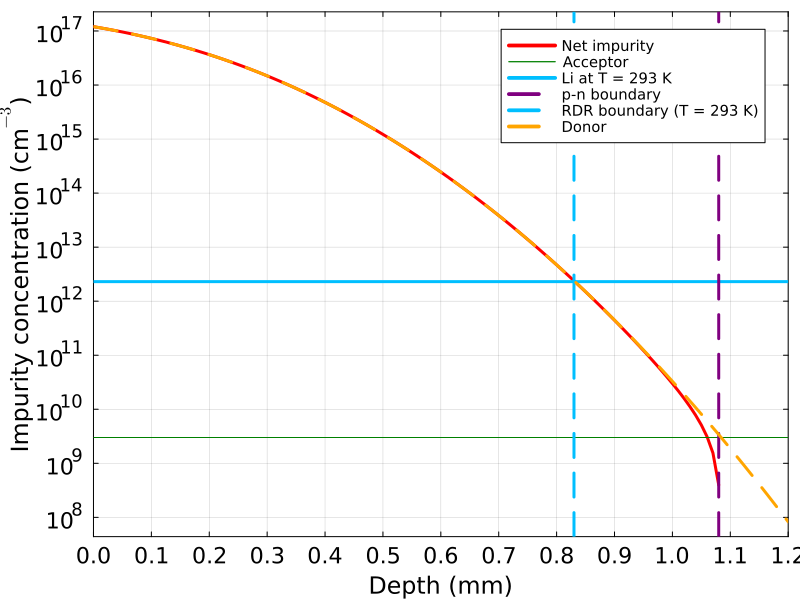

In [20]:

using LaTeXStrings

x = 0:0.001: 0.12

idx_pn = findall(abs.(Nd.(x) .- Na) .< 1e9)  # tolerance for numerical comparison
idx_RDR = findall(abs.(Nd.(x) .- N_Li_amb) .< 1e13)  # tolerance for numerical comparison
idx_RDR_amb = findall(abs.(Nd.(x) .- Ns_amb) .< 1e11) 
x_PN = x[idx_pn][1]  # take the first intersection
x_RDR = x[idx_RDR][1]  # take the first intersection
x_RDR_amb = x[idx_RDR_amb][1]  # take the first intersection

mask = NI_net.(x) .> 0

p = plot(x[mask] .* 10,
     NI_net.(x[mask]),
     label="Net impurity",
     color = :red,
     yscale=:log10,
     frame = :box, lw = 3)
hline!([Na], label="Acceptor", color=:green)
hline!([Ns_amb], label="Li at T = 293 K", color=:deepskyblue, lw=3)
vline!([x_PN*10], label="p-n boundary", color=:purple, lw=3, ls = :dash,)
#vline!([x_RDR*10], label="RDR boundary", color=:deepskyblue, lw=3)
vline!([x_RDR_amb*10], label="RDR boundary (T = 293 K)", color=:deepskyblue, lw=3, ls = :dash)
#hline!([N_Li_amb], label="Li( T = 300 K )", color=:deepskyblue, lw=2)
plot!(x .* 10, Nd.(x),
     label="Donor",
     color=:orange,
     ls=:dash, yscale= :log10,
     lw = 3)
plot!(xticks = 0:0.1:1.2, 
     yticks = 10 .^ (0:1:17),
     xguidefontsize = 16,          # dimensione label asse x
    yguidefontsize = 16,          # dimensione label asse y
    tickfontsize = 15,             # dimensione numeri dei tick su entrambi gli assi
    legendfontsize = 10 ,  
     xlims=(0, 1.2), xlabel="Depth (mm)", ylabel="Impurity concentration (cm\$^{-3}\$)",  legend=:topright, size=(800, 600))
savefig("plot/Impurity_profile_RDR.png")
display(p)


In [15]:
x_RDR_amb

0.083

In [8]:
x_RDR

0.065

In [19]:
α = 1.6e-11
T_diff = 90 #K
r_Li = 20e-4 #cm
function τ_hole(x, α)
    m0 = 9.11e-31 #kg
    m_eff_hole = 0.21 * m0
    kB = 1.38e-23 #J/K
    v_th = sqrt(3 * kB * T_diff / m_eff_hole) * 1e-2   # cm/s
    σ_trap = π * (r_Li)^2
    Nd_val = Ns * erfc.(x ./ (2 * sqrt(D_Li * t_ann)))   #cm^.3

    τ_h = 1 ./ (α .* Nd_val .* v_th .* σ_trap)
    return τ_h
end

τ_hole (generic function with 1 method)

In [20]:
function P_trapping(Δt, x, α)
    # Δt --> ns
    τ_hole_ns = τ_hole(x, α) .* 1e9  # convert to ns
    return 1 .- exp.(-Δt ./ τ_hole_ns)
end

P_trapping (generic function with 1 method)

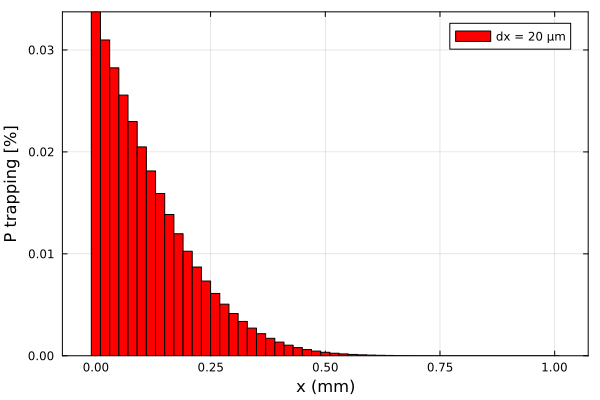

In [30]:
using StatsPlots

using StatsPlots

dx = 2e-3          # 20 μm = 0.002 cm
x_min = 0.0
x_max = 0.1        # cm (1 mm)
x_grid = collect(x_min:dx:x_max)

P_vals = P_trapping(10, x_grid, α)

# Converti in mm per il plot
x_mm = x_grid .* 10
dx_mm = dx * 10     # larghezza barra in mm

bar(x_mm, P_vals .* 100,
    bar_width = dx_mm,
    xlabel = "x (mm)",
    ylabel = "P trapping [%]",
    label = "dx = 20 μm",
    color = :red,
    frame = :box)